# MAS

In [11]:
from src import Model
from pydantic import Field
from enum import Enum

class Status(Enum):
    TODO='todo'
    IN_PROGRESS='in_progress'
    ON_PAUSE='on_pause'
    REVIEW='review'
    DONE='done'
    REMOVED='removed'

In [19]:
class _Task(Model):
    name : str = Field(description='Название задачи')
    description : str = Field(description='Описание задачи')

class Task(_Task):
    id : str = Field(description='ID задачи')
    # status : Status = Field(default=Status.TODO, description='Статус задачи')
    created_at : int = Field(description='Номер итерации, на которой была создана задача')

In [20]:
class _Comment(Model):
    author : str = Field(description='Автор комментария')
    content : str = Field(max_length=140, description='Содержание комментария')

class Comment(_Comment):
    task_id : str = Field(description='ID задачи')
    created_at : int = Field(description='Номер итерации, на которой был создан комментарий')

In [23]:
class _Result(Model):
    author : str = Field(description='Автор результата')
    content : str = Field(description="Содержание результата")

class Result(_Result):
    task_id : str = Field(description='ID задачи')
    created_at : int = Field(description='Номер итерации, на которой был создан комментарий')

In [24]:
import uuid
import threading

def generate_id():
    return str(uuid.uuid4()).replace('-', '')

lock = threading.Lock()

In [26]:
class Board(Model):
    iteration : int = Field(default=0)
    tasks : list[Task] = Field(default=[])
    comments : list[Comment] = Field(default=[])
    results : list[Result] = Field(default=[])

    def add_tasks(self, tasks : list[_Task]) -> list[str]:
        """
        Добавляет перечень задач на доску задач
        Возвращает список ID задач по порядку добавления.
        """
        with lock:
            tasks = [Task(
                id=generate_id(),
                created_at=self.iteration,
                **task.model_dump()
            ) for task in tasks]
            self.tasks = tasks
            return [t.id for t in self.tasks]

    def get_task(self, task_id : str) -> Task | None:
        """
        Возвращает задачу по ID. 
        Возвращает None, если задача не найдена.
        """
        tasks = list(filter(lambda t : t.id == task_id, self.tasks))
        if len(tasks) == 0:
            return None
        return tasks[0]

    def get_tasks(self, status : Status | None = None) -> list[Task]:
        """
        Возвращает перечень доступных задач для выполнения с фильтром по статусу (опционально).
        Если фильтр не указан, вернется весь перечень задач.
        """
        tasks = self.tasks
        if status is not None:
            tasks = [task.status == status for task in tasks]
        return tasks

    def add_comment(self, task_id : str, comment : _Comment) -> Comment | None:
        """
        Добавляет комментарий к задаче. 
        Возвращает None, если задача с таким ID не найдена.
        Комментарии должны быть короткими.
        """
        task = self.get_task(task_id)
        if task is None:
            return None
        with lock:
            comment = Comment(
                task_id=task.id,
                created_at=self.iteration,
                **comment.model_dump()
            )
            self.comments.append(comment)
            return comment

    def get_comments(self, task_id : str) -> list[Comment] | None:
        """
        Возвращает комментарии, относящиеся к задаче. 
        Возвращает None, если задача с таким ID не найдена.
        """               
        task = self.get_task(task_id)
        if task is None:
            return None
        comments = [c for c in self.comments if c.task_id == task.id]
        return comments
    
    def add_result(self, task_id : str, result : _Result) -> Result | None:
        """
        Добавляет результат к задаче. 
        Возвращает None, если задача с таким ID не найдена.
        """
        task = self.get_task(task_id)
        if task is None:
            return None
        with lock:
            result = Result(
                task_id=task.id,
                created_at=self.iteration,
                **result.model_dump()
            )
            self.results.append(result)
            return result
        
    def get_results(self, task_id : str) -> list[Comment] | None:
        """
        Возвращает результаты, относящиеся к задаче. 
        Возвращает None, если задача с таким ID не найдена.
        """               
        task = self.get_task(task_id)
        if task is None:
            return None
        results = [c for c in self.results if c.task_id == task.id]
        return results

from langchain.tools import tool

board = Board()

tools = {
    'add_tasks': tool(board.add_tasks),
    'get_task': tool(board.get_task),
    'get_tasks': tool(board.get_tasks),
    'add_comment': tool(board.add_comment),
    'get_comments': tool(board.get_comments),
    'add_result': tool(board.add_result),
    'get_results': tool(board.get_results)
}

manager_tools = [
    tools['add_tasks'],
    tools['get_task'],
    tools['get_tasks'],
    tools['get_results']
    # tools['add_comment'],
    # tools['get_comments'],
]

agent_tools = [
    tools['get_task'],
    tools['get_tasks'],
    tools['add_result'],
    tools['get_results']
    # tools['add_comment'],
    # tools['get_comments'],
]

In [27]:
from src import Agent

class ManagerResponse(Model):
    to_continue : bool = Field(default=True, description='Продолжать выполнение итераций')
    response : str | None = Field(default=None, description='Финальный ответ пользователю')

manager_agent = Agent(tools=manager_tools, system_prompt="""
Ты менеджер. Твои обязанности:
- Декомпозиция запроса пользователя и создание задач для агентов.
- Отслеживание прогресса по задачам.
- Суммаризация результатов и формирование ответа пользователю.
                      
ФОРМАТ ОТВЕТА:
- `CONTINUE` -- если агентам необходимо продолжать работу.
- Текстовый результат -- в качестве ответа пользователю.
""")

agent_prompt = """
Ты {role}. Твои обязанности:
- Проверка пула новых задач.
- Выполнение задач, относящихся к твоей специализации.

ПРАВИЛА РАБОТЫ:
- Если можешь, выполняй задачу без лишних слов.
- Если чего-то не хватает, напиши.
- Если не относится к тебе - ничего не делай.
"""

strategist_agent = Agent(
    tools=agent_tools, 
    system_prompt=agent_prompt.format(role='специалист по стратегическому планированию')
)

urbanist_agent = Agent(
    tools=agent_tools, 
    system_prompt=agent_prompt.format(role='специалист по урбанистике')
)

city_planner_agent = Agent(
    tools=agent_tools, 
    system_prompt=agent_prompt.format(role='специалист по территориальному планированию')
)

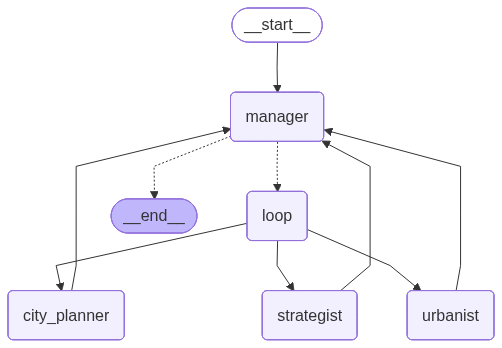

In [28]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain.messages import AIMessage

class State(MessagesState):
    # response : ManagerResponse
    pass

def loop_node(state : State):
    board.iteration = board.iteration + 1
    return {'messages': [AIMessage(f'Текущая итерация: {board.iteration}')]}

def manager_node(state : State):
    result = manager_agent.run(state['messages'])
    return {
        'messages': [AIMessage(result)]
    }

def create_agent_node(agent):

    def agent_node(state : State):
        result = agent.run([])
        return {'messages': [AIMessage(result)]}     
    
    return agent_node

graph = StateGraph(MessagesState)

graph.add_node('manager', manager_node)
graph.add_node('loop', loop_node)

for name,agent in {
    'strategist': strategist_agent,
    'urbanist': urbanist_agent,
    'city_planner': city_planner_agent
}.items():
    graph.add_node(name, create_agent_node(agent))
    graph.add_edge('loop', name)
    graph.add_edge(name, 'manager')

graph.add_edge(START, 'manager')

def loop_condition(state : State):
    message = state['messages'][-1]
    if 'CONTINUE' in message.content:
        return 'loop'
    return END
        
graph.add_conditional_edges('manager', loop_condition, ['loop', END])

app = graph.compile(debug=True)
app

In [29]:
app.invoke({'messages': ['Разработай целеполагание для г. Гатчины (в Ленинградской области)']})

[values] {'messages': [HumanMessage(content='Разработай целеполагание для г. Гатчины (в Ленинградской области)', additional_kwargs={}, response_metadata={}, id='d8e3ec12-2244-460d-bf95-6cb7fab96ead')]}
[updates] {'manager': {'messages': [AIMessage(content='CONTINUE', additional_kwargs={}, response_metadata={}, id='63230e2e-a5e6-4085-98bc-f67aba3b5c29', tool_calls=[], invalid_tool_calls=[])]}}
[values] {'messages': [HumanMessage(content='Разработай целеполагание для г. Гатчины (в Ленинградской области)', additional_kwargs={}, response_metadata={}, id='d8e3ec12-2244-460d-bf95-6cb7fab96ead'), AIMessage(content='CONTINUE', additional_kwargs={}, response_metadata={}, id='63230e2e-a5e6-4085-98bc-f67aba3b5c29', tool_calls=[], invalid_tool_calls=[])]}
[updates] {'loop': {'messages': [AIMessage(content='Текущая итерация: 1', additional_kwargs={}, response_metadata={}, id='fead7891-50d8-479b-b604-04b2182537b2', tool_calls=[], invalid_tool_calls=[])]}}
[values] {'messages': [HumanMessage(content=

InternalServerError: Error code: 500 - {'error': {'message': 'error parsing tool call: raw=\'{"task_id":"acb0e72d60634000858bef4d6048d706","result":{"city":"Гатчина","region":"Ленинградская область","population":{"total":94500,"year":2023,"growth_rate_percent":0.3,"age_structure":{"0-14":15.2,"15-64":66.8,"65+":18.0}},"demographics":{"ethnicity":{"russian":92.5,"ukrainian":2.1,"belarusian":1.8,"other":3.6}},"economy":{"key_sectors":["туризм","производство (машиностроение, легкая промышленность)","сельское хозяйство","услуги"],"unemployment_rate_percent":5.2,"average_monthly_income_rub":56000}},"infrastructure":{"transport":{"railway_station":"Гатчинская (Ленинградская железная дорога)","road_connections":["М-10 (Москва‑Санкт‑Петербург)","М-11 (Новгородская автодорога)"],"public_transport":"городской автобусный парк 45 маршрутов"},"utilities":{"water_supply":"Гатчинская водоканал","electricity":"Ленэнерго","gas":"Газпром"},"housing":{"total_floorspace_sq_m":12000000,"new_constructions_2

In [ ]:
board.model_dump()

{'iteration': 1,
 'tasks': [{'name': 'Сбор и анализ текущих данных о городе (демография, экономика, инфраструктура)',
   'description': 'Собрать статистику, отчеты, исследования по Гатчине, проанализировать сильные и слабые стороны.',
   'id': '317d354dff4347338248836a85e973d6',
   'created_at': 0,
   'result': None},
  {'name': 'Выявление ключевых заинтересованных сторон и их потребностей',
   'description': 'Определить органы власти, бизнес, гражданские организации, жители, их ожидания и приоритеты.',
   'id': 'a94ea8ecbc2e4551a4ba288971ded254',
   'created_at': 0,
   'result': None},
  {'name': 'Формулирование миссии и видения развития Гатчины',
   'description': 'Создать краткую миссию и вдохновляющее видение на 10-20 лет.',
   'id': 'c946ba6023494670a9c8c5747fbda551',
   'created_at': 0,
   'result': None},
  {'name': 'Определение стратегических целей',
   'description': 'Определить основные направления: экономика, социальная сфера, экология, культура, инфраструктура.',
   'id': '